# **Install required libraries**

In [98]:
!pip install -q diffusers transformers accelerate safetensors gdown pyngrok fastapi uvicorn pillow

# **Download your LoRA model from Google Drive**

In [99]:
import gdown

url = "https://drive.google.com/uc?id=1eLSUDSVVVHM5pGmAK94B9BRJtjwzFLZM"
output = "brandybot_lora.safetensors"

gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1eLSUDSVVVHM5pGmAK94B9BRJtjwzFLZM
From (redirected): https://drive.google.com/uc?id=1eLSUDSVVVHM5pGmAK94B9BRJtjwzFLZM&confirm=t&uuid=707d7a46-faec-45c3-b1ae-d61fd7550143
To: /kaggle/working/brandybot_lora.safetensors
100%|██████████| 743M/743M [00:06<00:00, 115MB/s]  


'brandybot_lora.safetensors'

**Verify**

In [100]:
!ls -lh

total 709M
-rw-r--r-- 1 root root 709M Jan  3 12:25 brandybot_lora.safetensors


# **Load SDXL base model + your LoRA**

In [101]:
import torch
from diffusers import StableDiffusionXLPipeline

base_model = "stabilityai/stable-diffusion-xl-base-1.0"

pipe = StableDiffusionXLPipeline.from_pretrained(
    base_model,
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True
).to("cuda")

# Load your trained LoRA
pipe.load_lora_weights(
    ".",
    weight_name="brandybot_lora.safetensors"
)

pipe.fuse_lora()

print("✅ SDXL + LoRA loaded successfully")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


✅ SDXL + LoRA loaded successfully


# **Test image generation**

Token indices sequence length is longer than the specified maximum sequence length for this model (162 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['visual balance high contrast composition on a dark background sharp geometric shapes and smooth edges sleek modern typography integrated with the symbol technology - driven and enterprise - level aesthetic elegant and powerful visual tone neon glow highlights without overpowering the design centered logo composition, symmetrical and balanced scalable logo design suitable for websites, apps, and billboards no complex background, logo - focused composition professional branding mockup quality ultra high resolution, crisp details high quality, modern logo generation']
Token indices sequence length is longer than the specified maximum sequence length for this model (162 > 77). Running this sequence through th

  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


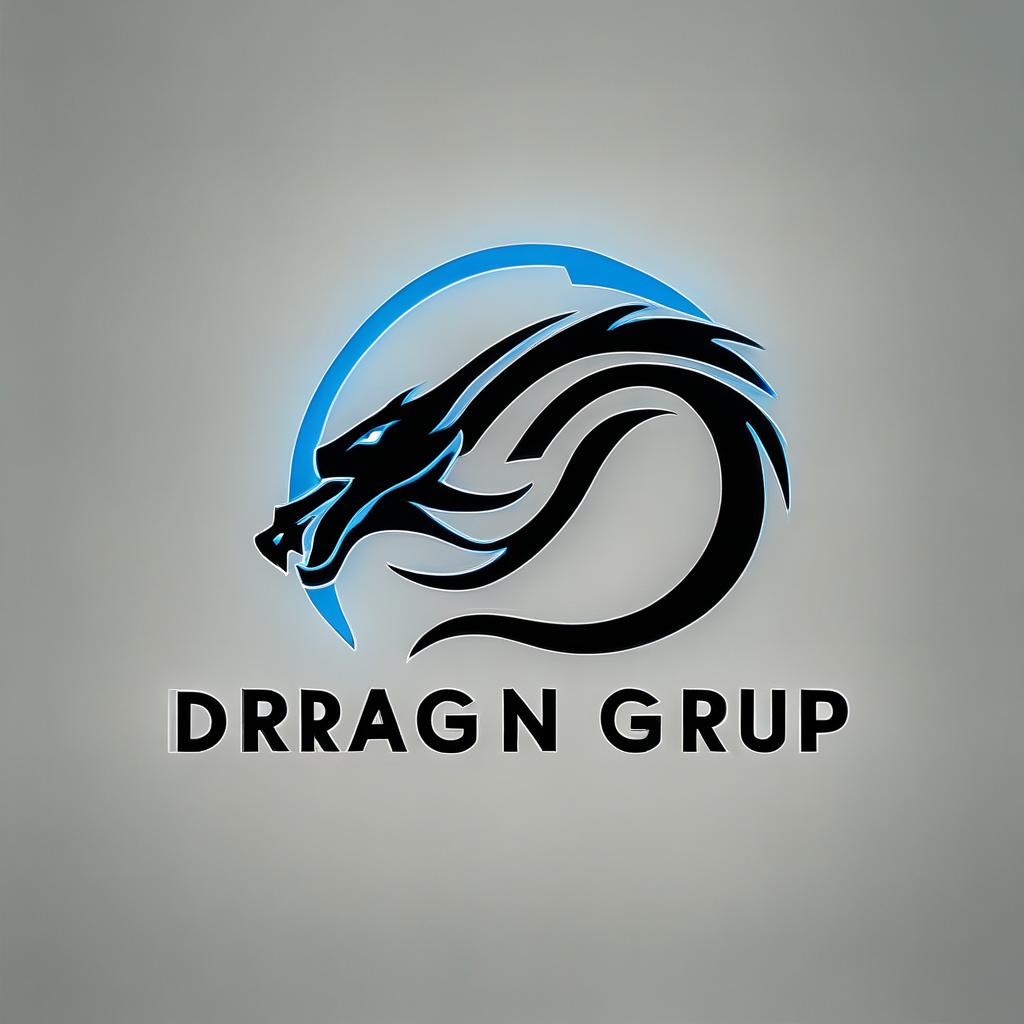

In [102]:
prompt1 = "modern minimal logo for a tech startup, flat vector style, brand identity"
negative_prompt1 = "blurry, low quality, watermark, text"

prompt = "A high-end professional logo design for a brand named 'Dragon Group' Futuristic and premium corporate brand identity Primary color palette of neon blue and deep black Secondary accents using subtle electric blue glow A stylized dragon symbol representing strength, leadership, and innovation Modern abstract dragon form, not cartoon or fantasy style Clean flat vector logo suitable for digital and print branding Minimal and bold design with strong visual balance High contrast composition on a dark background Sharp geometric shapes and smooth edges Sleek modern typography integrated with the symbol Technology-driven and enterprise-level aesthetic Elegant and powerful visual tone Neon glow highlights without overpowering the design Centered logo composition, symmetrical and balanced Scalable logo design suitable for websites, apps, and billboards No complex background, logo-focused composition Professional branding mockup quality Ultra high resolution, crisp details High quality, modern logo generation" 
negative_prompt = "low quality, blurry, pixelated, watermark, extra text, cartoon, anime, fantasy illustration, photorealistic, busy background, noisy, distorted, sketch, hand-drawn"

image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=30,
    guidance_scale=7.5
).images[0]

image

# **Create FastAPI app (API layer)**

In [103]:
from fastapi import FastAPI
from io import BytesIO
from PIL import Image
import base64

app = FastAPI()

@app.get("/")
def home():
    return {"status": "SDXL LoRA API is running"}

@app.post("/generate")
def generate(prompt: str):
    image = pipe(
        prompt=prompt,
        num_inference_steps=30,
        guidance_scale=7.5
    ).images[0]

    buffer = BytesIO()
    image.save(buffer, format="PNG")
    img_str = base64.b64encode(buffer.getvalue()).decode()

    return {"image_base64": img_str}

# **Run the server inside Kaggle (threaded)**

In [104]:
import threading
import uvicorn

def run():
    uvicorn.run(app, host="0.0.0.0", port=8000)

thread = threading.Thread(target=run)
thread.start()

INFO:     Started server process [55]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use
INFO:     Waiting for application shutdown.


**Check**

In [105]:
!curl http://localhost:8000

INFO:     Application shutdown complete.


INFO:     127.0.0.1:39774 - "GET / HTTP/1.1" 200 OK
{"status":"SDXL LoRA API is running"}

# **Generate ngrok public link**

In [106]:
from pyngrok import ngrok

ngrok.set_auth_token("3CYwksUJHKnZWtLM4WkvuJq95AH_Up5cUjPFaqjfg77z3Wdh")
public_url = ngrok.connect(8000)
print("🌍 Public URL:", public_url)

PyngrokNgrokHTTPError: ngrok client exception, API returned 502: {"error_code":103,"status_code":502,"msg":"failed to start tunnel","details":{"err":"failed to start tunnel: Your account may not run more than 5 endpoints over a single ngrok agent session.\nThe endpoints already running on this session are:\ntn_3CYpm7ejWS6WKwn1fXntJjy6OER, tn_3CYpzYGdMagvjOZULVGMVtpTxGY, tn_3CYpzlNc3TpEw1uHLKb4QC2DOpM, tn_3CYvcUovInWldx2ATbHRgrJ0zg3, tn_3CYvsa9HzvA9gFCX9IEF9P8mR8o.\nUpgrade to a Pay-as-you-go plan at: https://dashboard.ngrok.com/billing/choose-a-plan?plan=paygo\r\n\r\nERR_NGROK_324\r\n"}}


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
